# Проект: Линейные модели в машинном обучении

**Описание проекта**  
Вы работаете в IT-компании, которая выполняет на заказ проекты по машинному обучению. К вам обратился фермер, владелец молочного хозяйства «Вольный луг». Он хочет купить бурёнок, чтобы расширить поголовье стада коров. Для этого он заключил выгодный контракт с ассоциацией пастбищ «ЭкоФерма».  
Условия позволяют фермеру очень тщательно отобрать коров. Он определяет качество молока по строгой методике, и при этом ему нужно выполнять свой план развития молочного хозяйства. Фермер хочет, чтобы каждая бурёнка давала не менее 6000 килограммов молока в год, а её надой был вкусным — строго по его критериям, ничуть не хуже. А продавцы и технологи так и норовят приукрасить своих коровок!  
Поэтому он просит вас разработать модель машинного обучения, которая поможет ему управлять рисками и принимать объективное решение о покупке. «ЭкоФерма» готова предоставить подробные данные о своих коровах. Вам нужно создать две прогнозные модели для отбора бурёнок в поголовье:  
* Первая будет прогнозировать возможный удой коровы (целевой признак Удой);  
* Вторая — рассчитывать вероятность получить вкусное молоко от коровы (целевой признак Вкус молока).  

С помощью модели нужно отобрать коров по двум критериям:  
* Средний удой за год — не менее 6000 килограммов;  
* Молоко должно быть вкусным.  

**Описание данных**  
Файл ferma_main.csv содержит данные о стаде фермера на текущий момент.    
* id — уникальный идентификатор коровы.
* Удой, кг — масса молока, которую корова даёт в год (в килограммах).
* ЭКЕ (Энергетическая кормовая единица) — показатель питательности корма коровы.
* Сырой протеин, г — содержание сырого протеина в корме (в граммах).
* СПО (Сахаро-протеиновое соотношение) — отношение сахара к протеину в корме коровы.
* Порода — порода коровы.
* Тип пастбища — ландшафт лугов, на которых паслась корова.
* порода папы_быка — порода папы коровы.
* Жирность,% — содержание жиров в молоке (в процентах).
* Белок,% — содержание белков в молоке (в процентах).
* Вкус молока — оценка вкуса по личным критериям фермера, бинарный признак (вкусно, не вкусно).
* Возраст — возраст коровы, бинарный признак (менее_2_лет, более_2_лет).

Признаки в датасете ferma_main.csv можно разделить на группы.  
1. Характеристики коровы: id, Порода, порода папы_быка, Возраст.
2. Характеристики корма: ЭКЕ (Энергетическая кормовая единица), Сырой протеин, г, СПО (Сахаро-протеиновое соотношение).
3. Характеристика пастбища: Тип пастбища.
4. Характеристики молока: Удой, кг, Жирность,%, Белок,%, Вкус молока. 

Файл ferma_dad.csv хранит имя папы каждой коровы в стаде фермера.   
* id — уникальный идентификатор коровы.
* Имя Папы — имя папы коровы.

Файл cow_buy.csv — это данные о коровах «ЭкоФермы», которых фермер хочет изучить перед покупкой.  
* Порода — порода коровы.
* Тип пастбища — ландшафт лугов, на которых паслась корова.
* порода папы_быка — порода папы коровы.
* Имя_папы — имя папы коровы.
* Текущая_жирность,% — содержание жиров в молоке (в процентах).
* Текущий_уровень_белок,% — содержание белков в молоке (в процентах).
* Возраст — возраст коровы, бинарный признак (менее_2_лет, более_2_лет).

Данные в файлах ferma_main.csv и cow_buy.csv похожи, но у датасета cow_buy.csv несколько особенностей:  
1. Содержание белков и жиров в молоке указано на момент продажи — когда «ЭкоФерма» давала коровам свой корм.  
2. Параметры корма ЭКЕ (Энергетическая кормовая единица), Сырой протеин, г и СПО (Сахаро-протеиновое соотношение) отсутствуют. Технологи заказчика пересмотрели подход к кормлению: для новых коров планируется увеличить значения каждого из этих параметров на 5%.
3. Кроме того, отсутствуют признаки Удой, кг и Вкус молока. Это целевые признаки, именно их предстоит предсказать!

**План проекта**
1. Загрузка данных
2. Предобработка данных
3. Исследовательский анализ данных
4. Проведение корреляционного анализа признаков в датасете ferma_main.csv
5. Постройка регрессионных моделей
6. Постройка классификационной модели
7. Общий вывод

## 1. Загрузка данных

### 1.1. Импорт библиотек

In [1]:
pip install --upgrade scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as st
from scipy.stats import spearmanr
import numpy as np
import seaborn as sns
from pylab import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score, roc_curve, auc
from sklearn.metrics import precision_recall_curve

### 1.2. Загрузка данных

In [3]:
df_main = pd.read_csv('/datasets/ferma_main.csv', sep=';')
df_dad = pd.read_csv('/datasets/ferma_dad.csv', sep=';')
df_cow_buy = pd.read_csv('/datasets/cow_buy.csv', sep=';')

### 1.3. Изучение данных

#### 1.3.1. Изучение данных о стаде фермера

In [4]:
display(df_main.head())

,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст
0,1,5863,"14,2",1743,"0,89",Вис Бик Айдиал,Равнинное,Айдиал,"3,58","3,076",вкусно,более_2_лет
1,2,5529,"12,8",2138,"0,89",Вис Бик Айдиал,Равнинные,Соверин,"3,54","3,079",вкусно,менее_2_лет
2,3,5810,14,1854,"0,885",РефлешнСоверинг,Холмистое,Соверин,"3,59","3,074",не вкусно,более_2_лет
3,4,5895,"12,4",2012,"0,885",РефлешнСоверинг,Холмистое,Айдиал,"3,4","3,075",не вкусно,более_2_лет
4,5,5302,"12,8",1675,"0,885",Вис Бик Айдиал,Равнинные,Соверин,"3,73","3,073",вкусно,менее_2_лет


In [5]:
display(df_main.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   id                                     634 non-null    int64 
 1   Удой, кг                               634 non-null    int64 
 2   ЭКЕ (Энергетическая кормовая единица)  634 non-null    object
 3   Сырой протеин, г                       634 non-null    int64 
 4   СПО (Сахаро-протеиновое соотношение)   634 non-null    object
 5   Порода                                 634 non-null    object
 6   Тип пастбища                           634 non-null    object
 7   порода папы_быка                       634 non-null    object
 8   Жирность,%                             634 non-null    object
 9   Белок,%                                634 non-null    object
 10  Вкус молока                            634 non-null    object
 11  Возраст            

None

#### 1.3.2. Изучение данных о отцах коров в стаде фермера

In [6]:
display(df_dad.head())

,id,Имя Папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


In [7]:
display(df_dad.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        629 non-null    int64 
 1   Имя Папы  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB


None

#### 1.3.3. Изучение данных о коровах «ЭкоФермы»

In [8]:
display(df_cow_buy.head(20))

,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,54","3,081",менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,061",более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,"3,64","3,074",более_2_лет
5,РефлешнСоверинг,равнинное,Соверин,Геркулес,"3,63","3,053",менее_2_лет
6,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
7,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,57","3,079",более_2_лет
8,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
9,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,079",менее_2_лет


In [9]:
display(df_cow_buy.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Порода                   20 non-null     object
 1   Тип пастбища             20 non-null     object
 2   порода папы_быка         20 non-null     object
 3   Имя_папы                 20 non-null     object
 4   Текущая_жирность,%       20 non-null     object
 5   Текущий_уровень_белок,%  20 non-null     object
 6   Возраст                  20 non-null     object
dtypes: object(7)
memory usage: 1.2+ KB


None

**Выводы:**
* В таблицах df_main, df_cow_buy неправильный тип данных некоторых столбцов;
* В таблице df_dad содержится 629 записей, а в df_main 634, значит возможно есть дубликаты;
* В данных таблицах нет пропусков;
* Также стоит разобраться с наименованиями столбцов для будущего удобства использования.

## 2. Предобработка данных

### 2.1. Изменение названий столбцов

In [10]:
df_main.columns = ['id', 'milk_yield', 'efu', 'raw_protein', 'spr', 'breed', 'type_pasture', 'dad_breed', 'fat_content', 'protein', 'taste_milk', 'age']
df_dad.columns = ['id', 'dad_name']
df_cow_buy.columns = ['breed', 'type_pasture', 'dad_breed', 'dad_name', 'fat_content', 'protein', 'age']

### 2.2. Обработка явных дубликатов

In [11]:
display('Количество дубликатов в df_main', df_main.duplicated().value_counts())
display('Количество дубликатов в df_dad', df_dad.duplicated().value_counts())
display('Количество дубликатов в df_cow_buy', df_cow_buy.duplicated().value_counts())

'Количество дубликатов в df_main'

False    629
True       5
dtype: int64

'Количество дубликатов в df_dad'

False    629
dtype: int64

'Количество дубликатов в df_cow_buy'

False    16
True      4
dtype: int64

In [12]:
df_main = df_main.drop_duplicates(keep='first')

display('Количество дубликатов в df_main', df_main.duplicated().value_counts())

'Количество дубликатов в df_main'

False    629
dtype: int64

### 2.3. Обработка неявных дубликатов

In [13]:
display(df_main['type_pasture'].unique())
display(df_main['dad_breed'].unique())

array(['Равнинное', 'Равнинные', 'Холмистое'], dtype=object)

array(['Айдиал', 'Соверин', 'Айдиалл'], dtype=object)

In [14]:
df_main.loc[df_main['type_pasture'] == 'Равнинные', 'type_pasture'] = 'Равнинное'
df_main.loc[df_main['dad_breed'] == 'Айдиалл', 'dad_breed'] = 'Айдиал'

display(df_main['type_pasture'].unique())
display(df_main['dad_breed'].unique())

array(['Равнинное', 'Холмистое'], dtype=object)

array(['Айдиал', 'Соверин'], dtype=object)

### 2.4. Перевод в нижний регист

In [15]:
df_main.loc[df_main['breed'] == 'РефлешнСоверинг', 'breed'] = 'Рефлешн Соверинг'
for columns in ['breed', 'type_pasture', 'dad_breed', 'taste_milk']:
    df_main[columns] = df_main[columns].str.lower()

for columns in ['dad_name']:
    df_dad[columns] = df_dad[columns].str.lower()

df_cow_buy.loc[df_cow_buy['breed'] == 'РефлешнСоверинг', 'breed'] = 'Рефлешн Соверинг'
for columns in ['breed', 'type_pasture', 'dad_breed', 'dad_name']:
    df_cow_buy[columns] = df_cow_buy[columns].str.lower()

In [16]:
display(df_main.head())

,id,milk_yield,efu,raw_protein,spr,breed,type_pasture,dad_breed,fat_content,protein,taste_milk,age
0,1,5863,"14,2",1743,"0,89",вис бик айдиал,равнинное,айдиал,"3,58","3,076",вкусно,более_2_лет
1,2,5529,"12,8",2138,"0,89",вис бик айдиал,равнинное,соверин,"3,54","3,079",вкусно,менее_2_лет
2,3,5810,14,1854,"0,885",рефлешн соверинг,холмистое,соверин,"3,59","3,074",не вкусно,более_2_лет
3,4,5895,"12,4",2012,"0,885",рефлешн соверинг,холмистое,айдиал,"3,4","3,075",не вкусно,более_2_лет
4,5,5302,"12,8",1675,"0,885",вис бик айдиал,равнинное,соверин,"3,73","3,073",вкусно,менее_2_лет


### 2.5. Обработка выбросов

In [17]:
display(df_main.sort_values(by='milk_yield', ascending=False).head())
display(df_main.sort_values(by='efu', ascending=False).head())
display(df_main.sort_values(by='raw_protein', ascending=False).head())

,id,milk_yield,efu,raw_protein,spr,breed,type_pasture,dad_breed,fat_content,protein,taste_milk,age
16,17,45616,"11,5",1675,"0,93",вис бик айдиал,холмистое,айдиал,"3,22","3,076",вкусно,более_2_лет
70,71,7222,"16,8",2157,"0,95",вис бик айдиал,холмистое,айдиал,"3,7","3,076",вкусно,более_2_лет
135,136,7207,"16,6",2343,"0,94",вис бик айдиал,холмистое,айдиал,"3,72","3,078",вкусно,более_2_лет
296,297,7201,"15,8",2077,"0,94",рефлешн соверинг,холмистое,айдиал,"3,71","3,072",вкусно,более_2_лет
294,295,7197,"15,6",2241,"0,94",рефлешн соверинг,холмистое,айдиал,"3,71","3,075",вкусно,более_2_лет


,id,milk_yield,efu,raw_protein,spr,breed,type_pasture,dad_breed,fat_content,protein,taste_milk,age
70,71,7222,"16,8",2157,"0,95",вис бик айдиал,холмистое,айдиал,"3,7","3,076",вкусно,более_2_лет
352,353,7031,"16,8",2308,"0,95",вис бик айдиал,холмистое,айдиал,"3,73","3,08",вкусно,более_2_лет
282,283,6701,"16,8",2077,"0,95",рефлешн соверинг,холмистое,соверин,"3,69","3,072",вкусно,более_2_лет
503,504,7113,"16,7",1921,"0,95",вис бик айдиал,холмистое,айдиал,"3,72","3,077",вкусно,более_2_лет
303,304,6649,"16,7",2207,"0,94",рефлешн соверинг,холмистое,соверин,"3,72","3,07",вкусно,более_2_лет


,id,milk_yield,efu,raw_protein,spr,breed,type_pasture,dad_breed,fat_content,protein,taste_milk,age
423,424,6991,"16,7",2349,"0,95",вис бик айдиал,равнинное,айдиал,"3,73","3,08",не вкусно,более_2_лет
497,498,6584,"16,4",2346,"0,95",рефлешн соверинг,равнинное,соверин,"3,73","3,078",не вкусно,более_2_лет
135,136,7207,"16,6",2343,"0,94",вис бик айдиал,холмистое,айдиал,"3,72","3,078",вкусно,более_2_лет
235,236,6470,"16,7",2341,"0,95",вис бик айдиал,холмистое,соверин,"3,73","3,081",вкусно,более_2_лет
472,473,6547,"13,7",2341,"0,94",вис бик айдиал,холмистое,айдиал,"3,72","3,079",вкусно,более_2_лет


In [18]:
df_main = df_main.query("milk_yield < 8000")
df_dad = df_dad.query("id != 17")

In [19]:
display(df_main.sort_values(by='milk_yield', ascending=False).head())

,id,milk_yield,efu,raw_protein,spr,breed,type_pasture,dad_breed,fat_content,protein,taste_milk,age
70,71,7222,"16,8",2157,"0,95",вис бик айдиал,холмистое,айдиал,"3,7","3,076",вкусно,более_2_лет
135,136,7207,"16,6",2343,"0,94",вис бик айдиал,холмистое,айдиал,"3,72","3,078",вкусно,более_2_лет
296,297,7201,"15,8",2077,"0,94",рефлешн соверинг,холмистое,айдиал,"3,71","3,072",вкусно,более_2_лет
294,295,7197,"15,6",2241,"0,94",рефлешн соверинг,холмистое,айдиал,"3,71","3,075",вкусно,более_2_лет
593,594,7174,"16,7",2318,"0,95",рефлешн соверинг,холмистое,айдиал,"3,72","3,074",вкусно,более_2_лет


### 2.6. Изменение типа данных

In [20]:
display(df_main.info())
display(df_cow_buy.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 628 entries, 0 to 628
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            628 non-null    int64 
 1   milk_yield    628 non-null    int64 
 2   efu           628 non-null    object
 3   raw_protein   628 non-null    int64 
 4   spr           628 non-null    object
 5   breed         628 non-null    object
 6   type_pasture  628 non-null    object
 7   dad_breed     628 non-null    object
 8   fat_content   628 non-null    object
 9   protein       628 non-null    object
 10  taste_milk    628 non-null    object
 11  age           628 non-null    object
dtypes: int64(3), object(9)
memory usage: 63.8+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   breed         20 non-null     object
 1   type_pasture  20 non-null     object
 2   dad_breed     20 non-null     object
 3   dad_name      20 non-null     object
 4   fat_content   20 non-null     object
 5   protein       20 non-null     object
 6   age           20 non-null     object
dtypes: object(7)
memory usage: 1.2+ KB


None

In [21]:
for col in ['fat_content', 'protein', 'efu', 'spr']:
    df_main.loc[:, col] = df_main[col].astype(str).str.replace(',', '.').astype(float)

for col in ['fat_content', 'protein']:
    df_cow_buy.loc[:, col] = df_cow_buy[col].astype(str).str.replace(',', '.').astype(float)

In [22]:
display(df_main.info())
display(df_cow_buy.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 628 entries, 0 to 628
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            628 non-null    int64  
 1   milk_yield    628 non-null    int64  
 2   efu           628 non-null    float64
 3   raw_protein   628 non-null    int64  
 4   spr           628 non-null    float64
 5   breed         628 non-null    object 
 6   type_pasture  628 non-null    object 
 7   dad_breed     628 non-null    object 
 8   fat_content   628 non-null    float64
 9   protein       628 non-null    float64
 10  taste_milk    628 non-null    object 
 11  age           628 non-null    object 
dtypes: float64(4), int64(3), object(5)
memory usage: 63.8+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   breed         20 non-null     object 
 1   type_pasture  20 non-null     object 
 2   dad_breed     20 non-null     object 
 3   dad_name      20 non-null     object 
 4   fat_content   20 non-null     float64
 5   protein       20 non-null     float64
 6   age           20 non-null     object 
dtypes: float64(2), object(5)
memory usage: 1.2+ KB


None

In [23]:
display(df_cow_buy)

,breed,type_pasture,dad_breed,dad_name,fat_content,protein,age
0,вис бик айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет
1,вис бик айдиал,равнинное,соверин,буйный,3.54,3.081,менее_2_лет
2,рефлешн соверинг,равнинное,соверин,барин,3.59,3.074,более_2_лет
3,рефлешн соверинг,холмистое,айдиал,буйный,3.40,3.061,более_2_лет
4,рефлешн соверинг,равнинное,айдиал,буйный,3.64,3.074,более_2_лет
5,рефлешн соверинг,равнинное,соверин,геркулес,3.63,3.053,менее_2_лет
6,вис бик айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет
7,вис бик айдиал,равнинное,соверин,буйный,3.57,3.079,более_2_лет
8,рефлешн соверинг,равнинное,соверин,барин,3.59,3.074,более_2_лет
9,рефлешн соверинг,холмистое,айдиал,буйный,3.40,3.079,менее_2_лет


**Выводы:**
* Произведена замена названий столбцов для лучшего понимания и единобразия;
* В df_main и df_cow_buy были найдены и устрены явные и неявные дубликаты;
* Данные были приведены в нижний регист для устранения возможных ошибок;
* В данных df_main был найден и удалён выброс связанный с очень высоким удоем коровы;
* Также были преобразованы типы данных в корректные.

## 3. Исследовательский анализ данных

### 3.1. Описательные статистики данных

In [24]:
display('Описательная статистика df_main', df_main.describe())
display('Описательная статистика df_cow_buy', df_cow_buy.describe())

'Описательная статистика df_main'

,id,milk_yield,efu,raw_protein,spr,fat_content,protein
count,628.000000,628.000000,628.000000,628.000000,628.000000,628.000000,628.000000
mean,315.474522,6125.968153,14.548726,1923.759554,0.913089,3.604268,3.075670
std,181.475367,475.857053,1.301777,182.832816,0.032221,0.168093,0.002551
min,1.000000,5204.000000,10.900000,1660.000000,0.840000,2.990000,3.069000
25%,158.750000,5749.750000,13.500000,1771.750000,0.890000,3.590000,3.074000
50%,315.500000,6132.500000,14.700000,1888.000000,0.930000,3.650000,3.076000
75%,472.250000,6501.000000,15.600000,2062.250000,0.940000,3.720000,3.077000
max,629.000000,7222.000000,16.800000,2349.000000,0.960000,3.750000,3.085000


'Описательная статистика df_cow_buy'

,fat_content,protein
count,20.000000,20.000000
mean,3.577500,3.069500
std,0.126818,0.010339
min,3.340000,3.046000
25%,3.510000,3.064000
50%,3.590000,3.074000
75%,3.650000,3.076000
max,3.770000,3.081000


*промежуточный вывод*

*df_main (основные данные о коровах):*

* В среднем, коровы дают около 6126 кг молока в год.
* Среднее значение ЭКЕ (энергетическая кормовая единица) составляет 14.55, сырого протеина - 1924.
* Средняя жирность молока - 3.60%, содержание белка - 3.08%.
* Имеется разброс в надоях (стандартное отклонение 476 кг), что указывает на разнородность стада.

*df_cow_buy (данные о коровах на продажу):*

* Средняя жирность молока - 3.58%, содержание белка - 3.07%.
* Показатели жирности и белка немного ниже, чем в основном датасете, но в целом сопоставимы.
* Стандартное отклонение значительно ниже, что говорит о большей однородности группы коров на продажу.

### 3.2. Визуализация факторов

In [25]:
def viz_num(df, column, title):
    """Визуализация числовой переменной с использованием гистограммы и ящика с усами."""

    plt.figure(figsize=(15, 5)) 

    plt.subplot(1, 2, 1)  
    sns.histplot(data=df[column], bins=20)
    plt.ylabel('Количество коров')
    plt.xlabel(column)

    plt.subplot(1, 2, 2)
    sns.boxplot(data=df[column])
    plt.ylabel(column)

    plt.suptitle(title) 
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [26]:
def viz_cat(df, column, title):
    """Визуализация категориальной переменной с использованием столбчатой диаграммы."""

    sns.catplot(data=df, x=column, kind='count', height=5, aspect=1.5)  
    plt.title(title)  
    plt.show()

#### 3.2.1. df_main

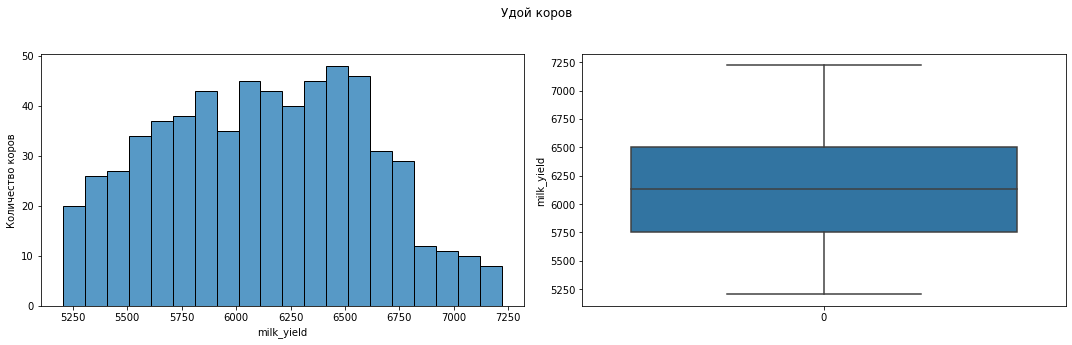

None

In [27]:
display(viz_num(df_main, 'milk_yield', 'Удой коров'))

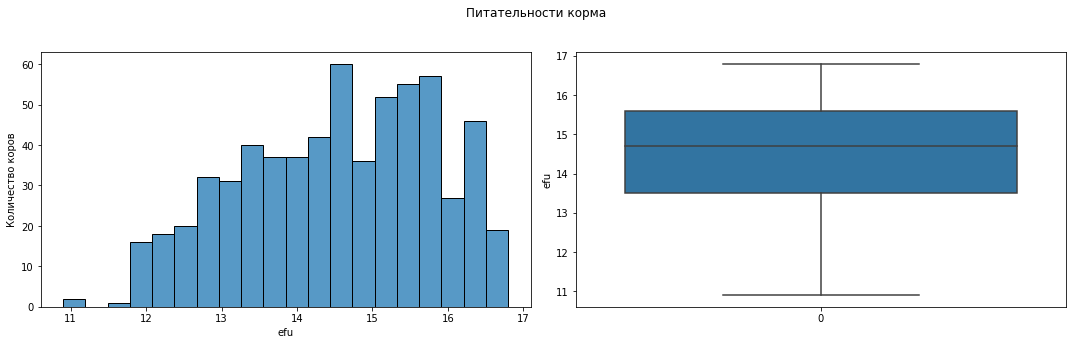

None

In [28]:
display(viz_num(df_main, 'efu', 'Питательности корма'))

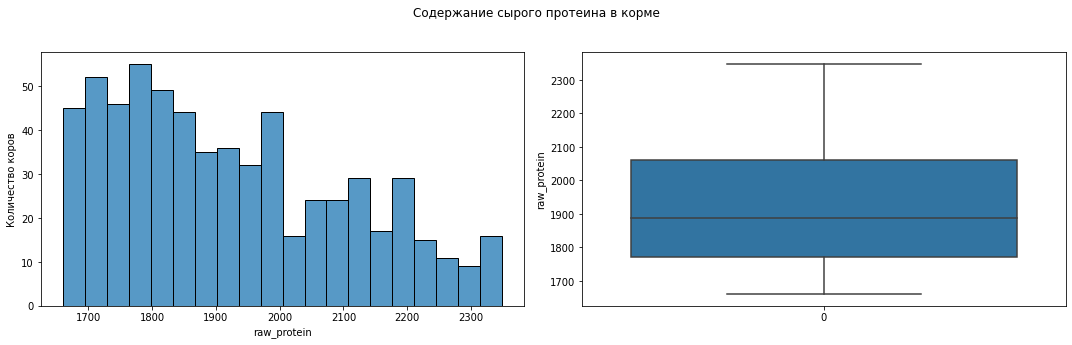

None

In [29]:
display(viz_num(df_main, 'raw_protein', 'Содержание сырого протеина в корме'))

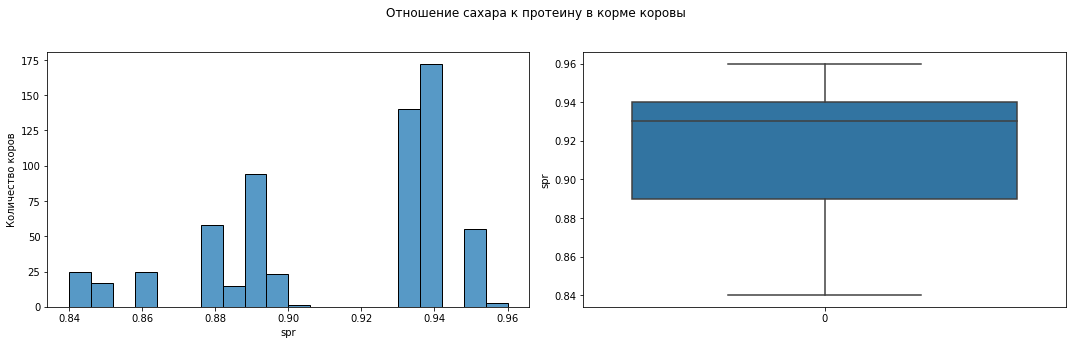

None

In [30]:
display(viz_num(df_main, 'spr', 'Отношение сахара к протеину в корме коровы'))

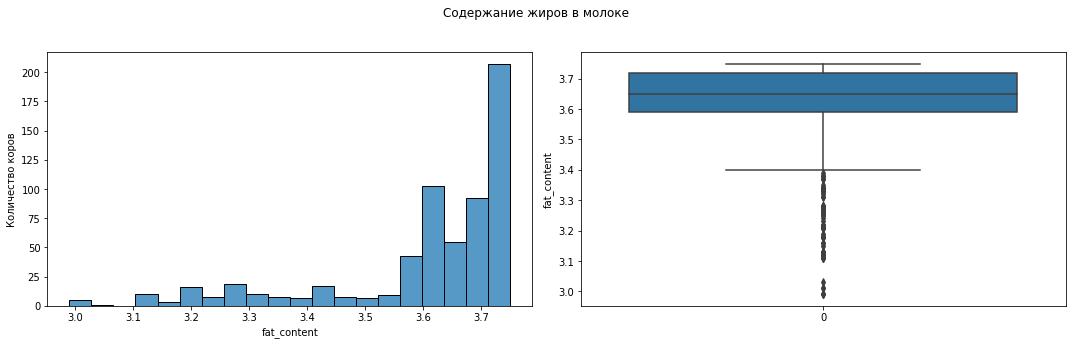

None

In [31]:
display(viz_num(df_main, 'fat_content', 'Содержание жиров в молоке'))

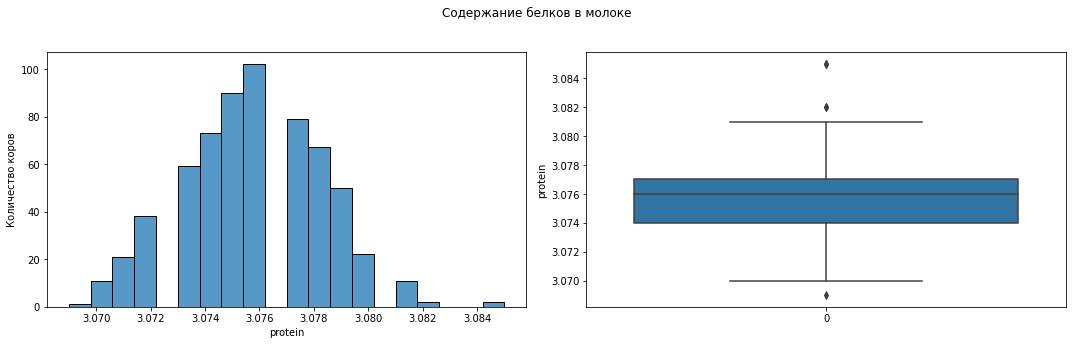

None

In [32]:
display(viz_num(df_main, 'protein', 'Содержание белков в молоке'))

In [33]:
def viz_num_2(df, column, title):
    """Визуализация числовой переменной с использованием гистограммы и ящика с усами.

    Учитывает правило Стёрджеса для выбора оптимального количества бинов для гистограммы.
    """

    plt.figure(figsize=(15, 5))

    n = len(df[column])
    bins = int(np.log2(n)) + 1

    plt.subplot(1, 2, 1)
    sns.histplot(data=df[column], bins=bins) 
    plt.ylabel('Количество коров')
    plt.xlabel(column)
    plt.title(f'Гистограмма (bins = {bins})')

    plt.subplot(1, 2, 2)
    sns.boxplot(data=df[column])
    plt.ylabel(column)

    plt.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

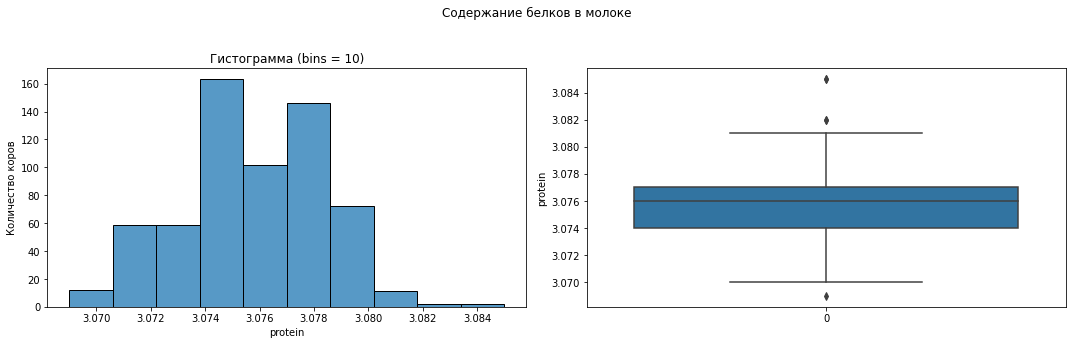

None

In [34]:
display(viz_num_2(df_main, 'protein', 'Содержание белков в молоке'))

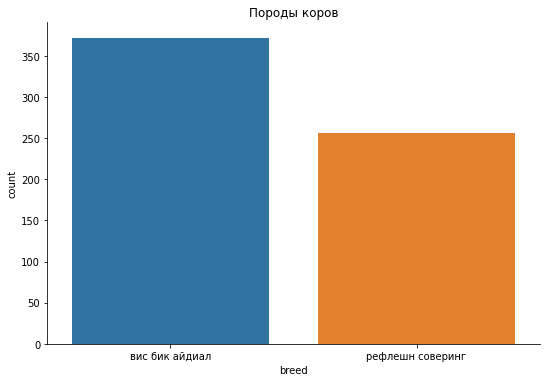

None

In [35]:
display(viz_cat(df_main, 'breed', 'Породы коров'))

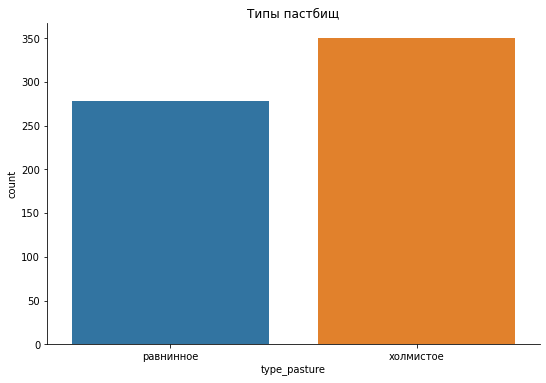

None

In [36]:
display(viz_cat(df_main, 'type_pasture', 'Типы пастбищ'))

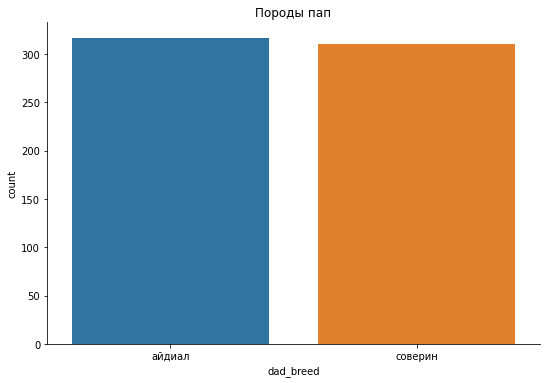

None

In [37]:
display(viz_cat(df_main, 'dad_breed', 'Породы пап'))

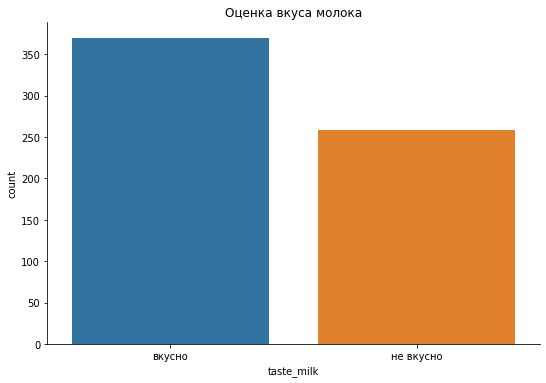

None

In [38]:
display(viz_cat(df_main, 'taste_milk', 'Оценка вкуса молока'))

*промежуточный вывод*  
Дисбаланс есть (вкусного молока больше). Accuracy - плохая метрика. Важнее:

* Precision: (главная метрика, минимизируем покупку коров с невкусным молоком).
* Recall, F1-score (баланс).
* AUC-ROC.
* Можно сделать сэмплирование (Можно использовать техники oversampling - увеличение количества примеров редкого класса или undersampling - уменьшение количества примеров частого класса).

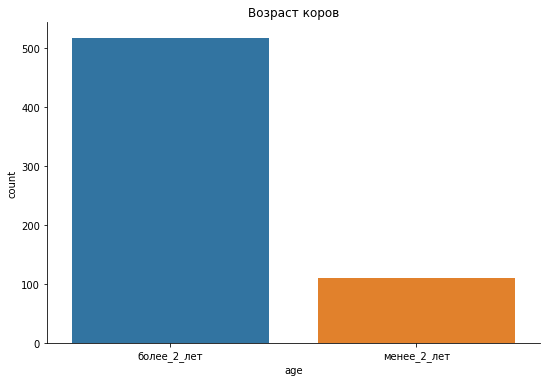

None

In [39]:
display(viz_cat(df_main, 'age', 'Возраст коров'))

#### 3.2.2. df_dad

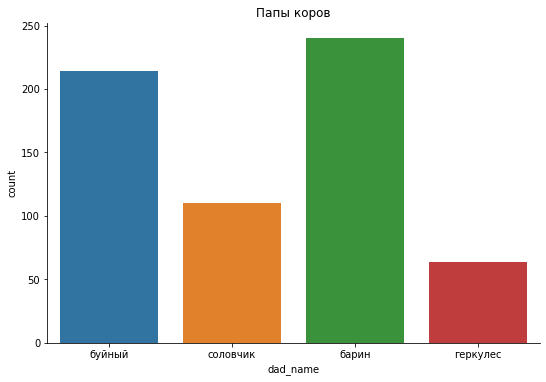

None

In [40]:
display(viz_cat(df_dad, 'dad_name', 'Папы коров'))

#### 3.2.3. df_cow_buy

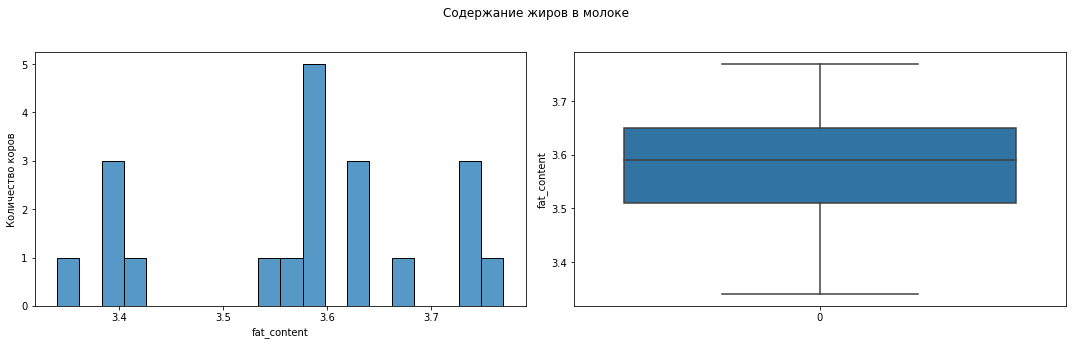

None

In [41]:
display(viz_num(df_cow_buy, 'fat_content', 'Содержание жиров в молоке'))

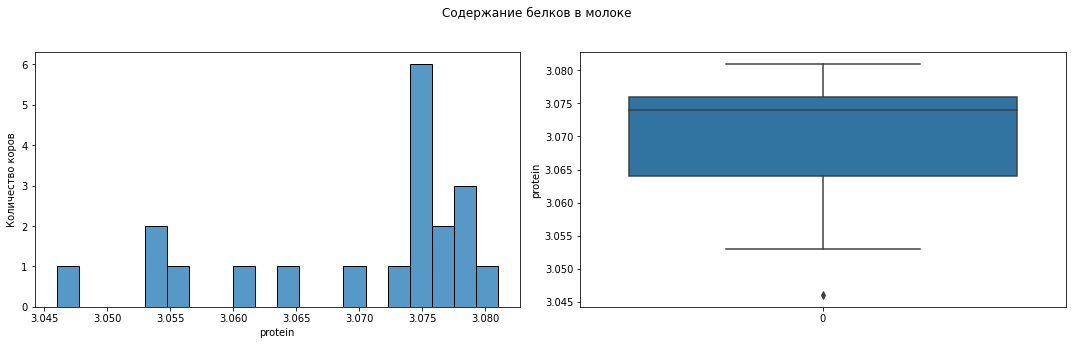

None

In [42]:
display(viz_num(df_cow_buy, 'protein', 'Содержание белков в молоке'))

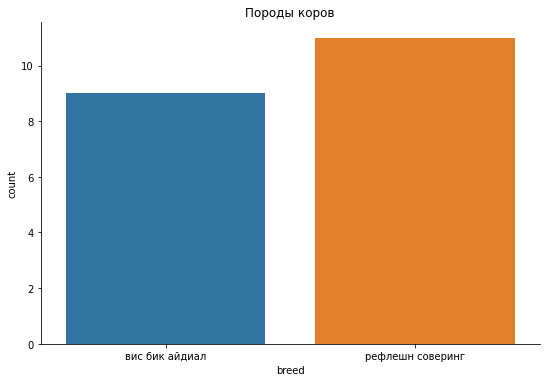

None

In [43]:
display(viz_cat(df_cow_buy, 'breed', 'Породы коров'))

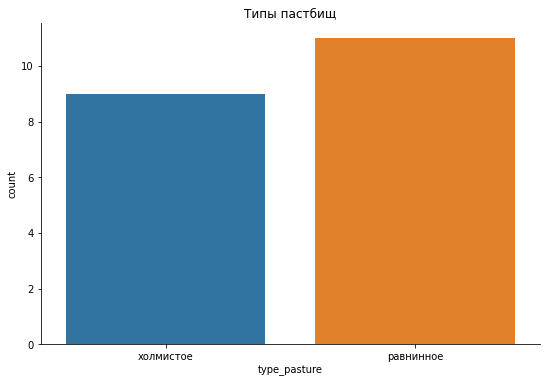

None

In [44]:
display(viz_cat(df_cow_buy, 'type_pasture', 'Типы пастбищ'))

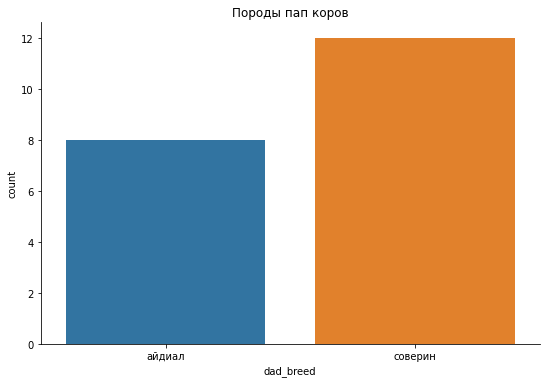

None

In [45]:
display(viz_cat(df_cow_buy, 'dad_breed', 'Породы пап коров'))

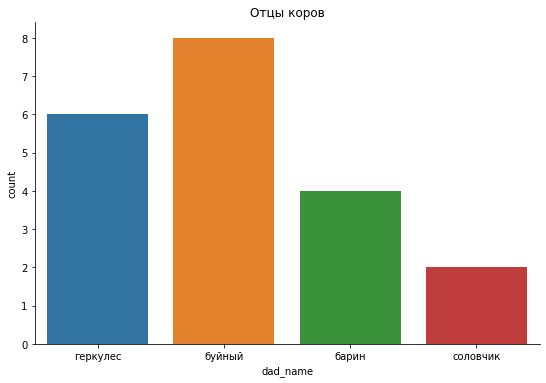

None

In [46]:
display(viz_cat(df_cow_buy, 'dad_name', 'Отцы коров'))

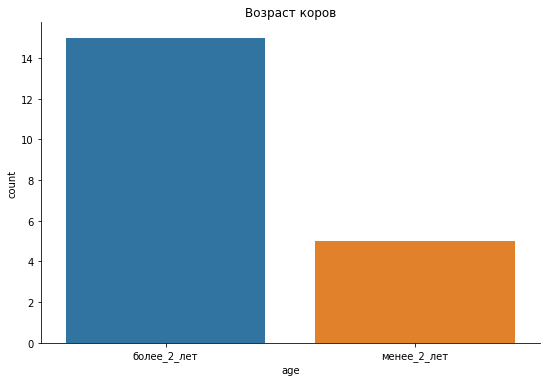

None

In [47]:
display(viz_cat(df_cow_buy, 'age', 'Возраст коров'))

**Выводы**
1. Данные о коровах фермера:
* Данные о удое распределены нормально. Средний удой коров более 6100 кг;
* ЭКЕ имеет среднее значение 14.7, график смещён в право;
* График сырого протеина в корме коров имеет среднее значнеие 1923, смещён влево;
* Содержание жира в молоке в среднем 3.65%. Имеются выбросы;
* Содержание белков в молоке имеет нормальное распределение, среднее значнеие 3.07;
* Отношение протеина к сахару среднее значение 0.93;
* По типу породы больше вис бик айдиал;
* Соотношение пород папы примерно равное;
* По типу пастбища больше холмистого;
* Вкусное молоко дает большая часть коров фермера;
* Большая часть коров старше 2 лет.
2. Данные о папах коров:
* Больше всего детей у барина, далее буйный, соловчик, геркулес.
3. Данные о коровах для покупки:
* Среднее содеражание жира в молоке около 3.6%;
* Содержание белка около 3.07;
* Соотношение по породе одинаковое;
* Соотношение по типу пастбища одинаковое;
* Соверин самая часта порода папы;
* Больше всего телят от Буйного;
* Большая часть коров старше 2 лет.

## 4. Корреляционный анализ

In [48]:
def s_corr(df, column_1, column_2):
    """
    Визуализирует корреляцию между двумя столбцами DataFrame для каждой породы на одном графике.

    Если признаки не распределены нормально, используется корреляция Спирмена.

    Args:
        df: pandas DataFrame с данными.
        column_1: Название первого столбца.
        column_2: Название второго столбца.
    """

    colors = {'вис бик айдиал': 'green', 'рефлешн соверинг': 'red'} 
    plt.figure(figsize=(10, 6))

    for breed, color in colors.items():
        subset = df[df['breed'] == breed] 

        method = 'spearman'  

        correlation = subset[column_1].corr(subset[column_2], method=method).round(2) 
        plt.scatter(subset[column_1], subset[column_2], label=f'{breed} (Corr: {correlation} - {method})', color=color, alpha=0.7) 

    plt.xlabel(column_1)
    plt.ylabel(column_2)
    plt.title(f"Корреляция между {column_1} и {column_2}") # Заголовок графика
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

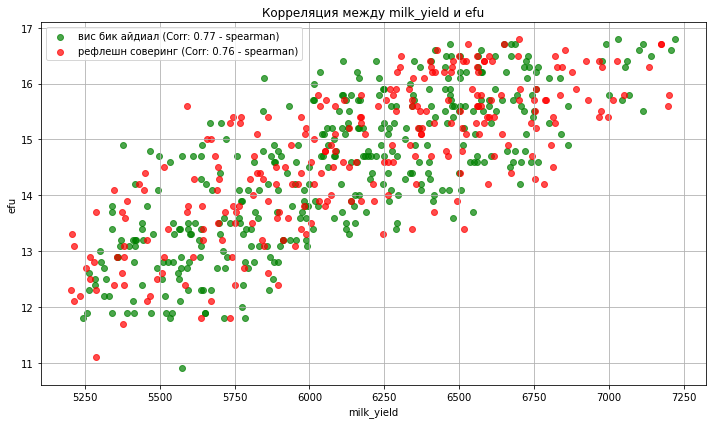

None

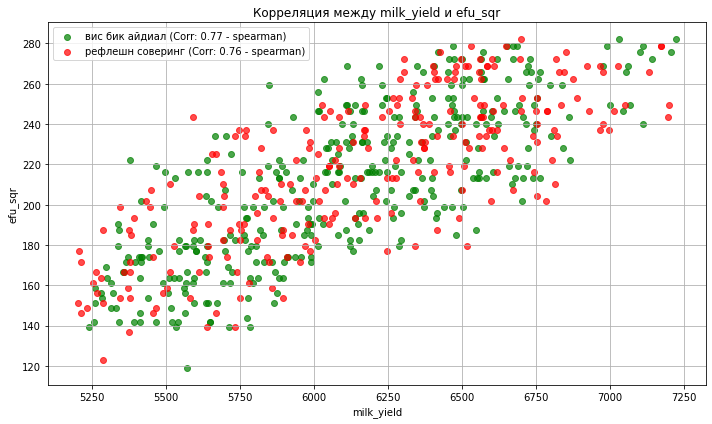

None

In [49]:
display(s_corr(df_main, 'milk_yield', 'efu'))
df_main['efu_sqr'] = df_main['efu']**2
display(s_corr(df_main, 'milk_yield', 'efu_sqr'))

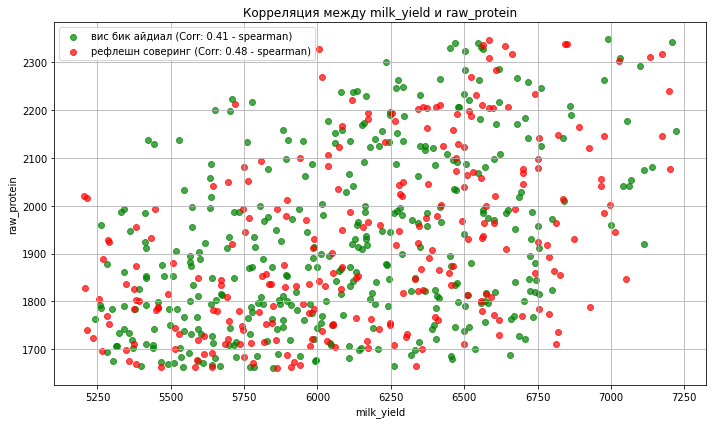

None

In [50]:
display(s_corr(df_main, 'milk_yield', 'raw_protein'))

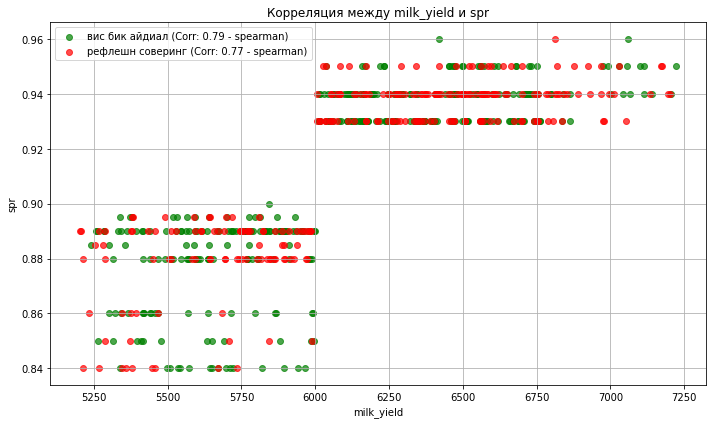

None

In [51]:
display(s_corr(df_main, 'milk_yield', 'spr'))

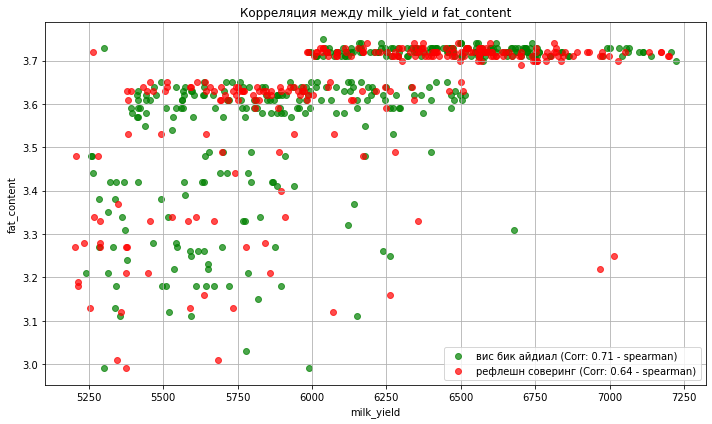

None

In [52]:
display(s_corr(df_main, 'milk_yield', 'fat_content'))

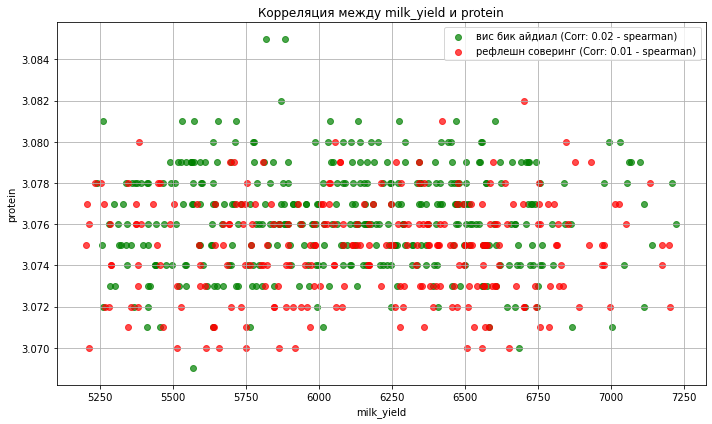

None

In [53]:
display(s_corr(df_main, 'milk_yield', 'protein'))

In [54]:
def heatmap_alternative(df, columns, title):
    """Визуализирует корреляционную матрицу в виде тепловой карты."""

    plt.figure(figsize=(14, 10))
    correlation_matrix = df[columns].corr(method = 'spearman')

    sns.heatmap(correlation_matrix, annot=True, cmap='cividis', fmt='.2f', linewidths=.5, annot_kws={'size': 12}) 

    plt.title(title, fontsize=24)
    plt.tight_layout()
    plt.show()

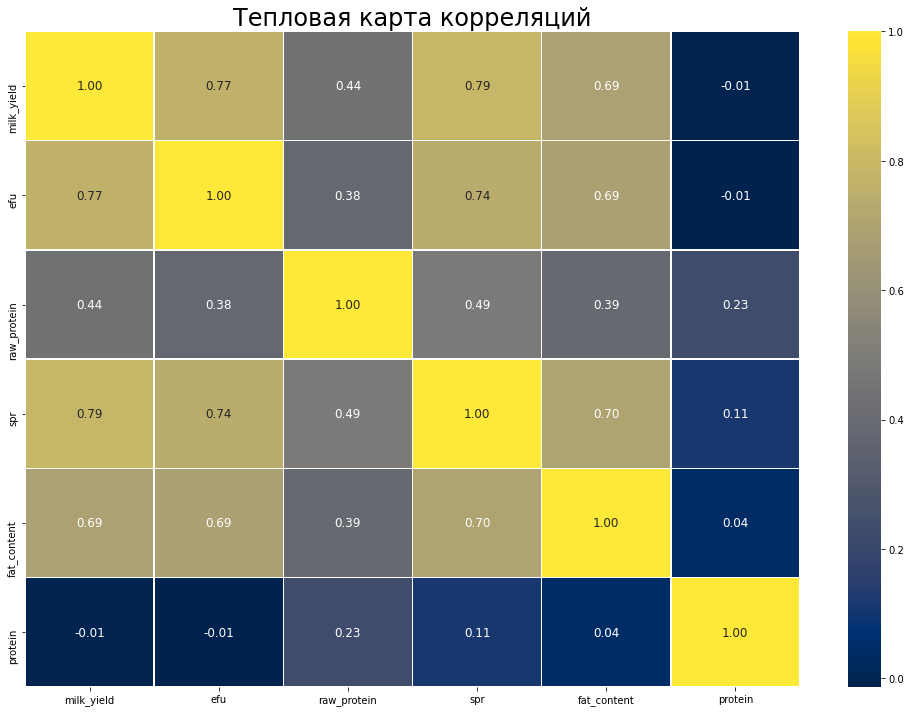

None

In [55]:
columns_to_use = ['milk_yield', 'efu', 'raw_protein', 'spr', 'fat_content', 'protein']
display(heatmap_alternative(df_main, columns_to_use, 'Тепловая карта корреляций'))

**Выводы**
* Целевой признак "Удой молока" имеет сильную линейную связь с "Энергетической кормовой единицей" (её можно описать дугой) и также линейную связь, но слабее с "Сырой протеин";
* Если ЭКЕ возвести в квадрат, то связь описывается прямой лучше, чем ранее;
* Корреляция между "Удой молока" и жирностью молока высокая, скорее всего из-за того что большая часть коров даёт жирное молоко;
* Нет корреляции с протеином у целевого признака "Удой молока";
* Мультиколинеарности нет;
* Также можно выделить СПО который чётко делит область на две части проявляя себя как категориальный признак.

## 5. Обучение модели линейной регрессии

In [56]:
def model(df, y, cat_col_names, num_col_names):
    """Обучение модели линейной регрессии с обработкой неизвестных категорий и дамми-ловушки."""

    RANDOM_STATE = 42

    X = df.drop(y, axis=1)
    y = df[y]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        random_state=RANDOM_STATE
    )

    encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
    X_train_ohe = encoder.fit_transform(X_train[cat_col_names])
    X_test_ohe = encoder.transform(X_test[cat_col_names])

    encoder_col_names = encoder.get_feature_names_out(cat_col_names)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train[num_col_names])
    X_test_scaled = scaler.transform(X_test[num_col_names])

    X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
    X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

    X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)

    X_train = pd.concat([X_train_ohe, X_train_scaled.set_index(X_train_ohe.index)], axis=1)
    X_test = pd.concat([X_test_ohe, X_test_scaled.set_index(X_test_ohe.index)], axis=1)

    model_lr  = LinearRegression()
    model_lr.fit(X_train, y_train)

    predictions = model_lr.predict(X_test)

    return [X_train, X_test, y_train, y_test, predictions, encoder, scaler, model_lr]

In [57]:
def R2(model, df, y, cat_col_names, num_col_names):
    """Анализ качества модели: R2."""
    
    model_m = model(df, y, cat_col_names, num_col_names)
    r2 = r2_score(model_m[3], model_m[4])
    return r2

def MSE(model, df, y, cat_col_names, num_col_names):
    """Анализ качества модели: MSE."""
    
    model_m = model(df, y, cat_col_names, num_col_names)
    mse = mean_squared_error(model_m[3], model_m[4])
    return mse

def MAE(model, df, y, cat_col_names, num_col_names):
    """Анализ качества модели: MAE."""
    
    model_m = model(df, y, cat_col_names, num_col_names)
    mae = mean_absolute_error(model_m[3], model_m[4])
    return mae

def RSME(model, df, y, cat_col_names, num_col_names):
    """Анализ качества модели: RSME."""
    
    model_m = model(df, y, cat_col_names, num_col_names)
    mse = mean_squared_error(model_m[3], model_m[4])
    rmse = np.sqrt(mse)
    return rmse

In [58]:
def quality_model_alternative(model, df, y, cat_col_names, num_col_names):
    """Анализ качества модели: гистограмма остатков, график рассеяния и QQ-plot."""

    model_results = model(df, y, cat_col_names, num_col_names) 
    predicted_values = model_results[4] 
    actual_values = model_results[3] 

    residuals = actual_values - predicted_values

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5)) 
    fig.suptitle("Анализ качества модели")

    sns.histplot(residuals, ax=axes[0], kde=True)  
    axes[0].set(title='Гистограмма распределения остатков', xlabel='Остатки', ylabel='Плотность')

    axes[1].scatter(predicted_values, residuals, alpha=0.5) 
    axes[1].set(xlabel='Предсказания модели', ylabel='Остатки', title='Анализ дисперсии')
    axes[1].axhline(y=0, color='r', linestyle='--')  

    st.probplot(residuals, dist="norm", plot=axes[2]) 
    axes[2].set_title("QQ-plot остатков")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

### 5.1. Обучение первой модели

'R2: 0.7844078173416966'

'MSE: 43887.01500966052'

'MAE: 164.2419446347493'

'RSME: 209.49227911706083'

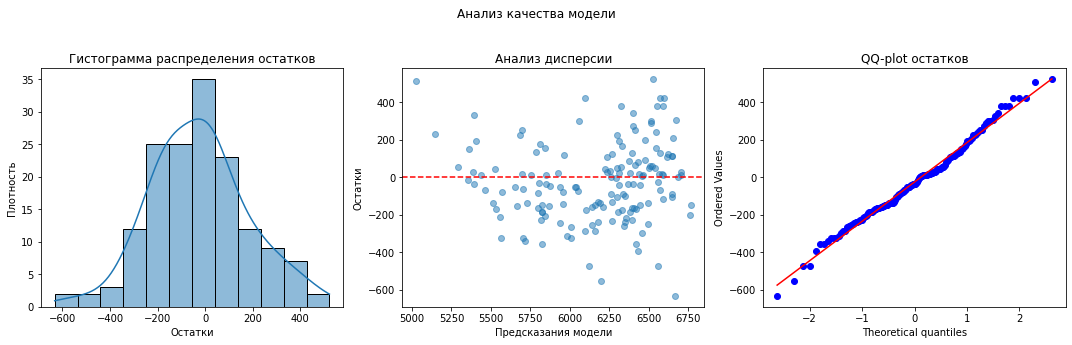

None

In [59]:
df = df_main
y = 'milk_yield'
cat_col_names = ['breed', 'type_pasture', 'dad_breed', 'age']
num_col_names = ['efu', 'spr', 'raw_protein']


display(f'R2: {R2(model, df, y, cat_col_names, num_col_names)}')
display(f'MSE: {MSE(model, df, y, cat_col_names, num_col_names)}')
display(f'MAE: {MAE(model, df, y, cat_col_names, num_col_names)}')
display(f'RSME: {RSME(model, df, y, cat_col_names, num_col_names)}')
display(quality_model_alternative(model, df, y, cat_col_names, num_col_names))

**Выводы:**
* По гистограмме видно смещение в лево, что нужно улучшать для более коректного предсказывания целевой переменной;
* Анализируя дисперсию можно сделать вывод, что она имеет воронко-образный вид, остатки распределены неравномерно;
* QQ-plot позволяет визуально оценить, насколько хорошо распределение остатков соответствует нормальному распределению. Хотя точки лежат достаточно близко к прямой, однако можно лучше. 

### 5.2. Обучение второй модели

In [60]:
df_main_2 = df_main[:]
df_main_2['spr'] = df_main_2['spr'].apply(lambda x: 'более_0.92' if x > 0.92 else 'менее_0.92')

'R2: 0.8180879926867501'

'MSE: 37030.91131113695'

'MAE: 149.03965222364604'

'RSME: 192.43417396901452'

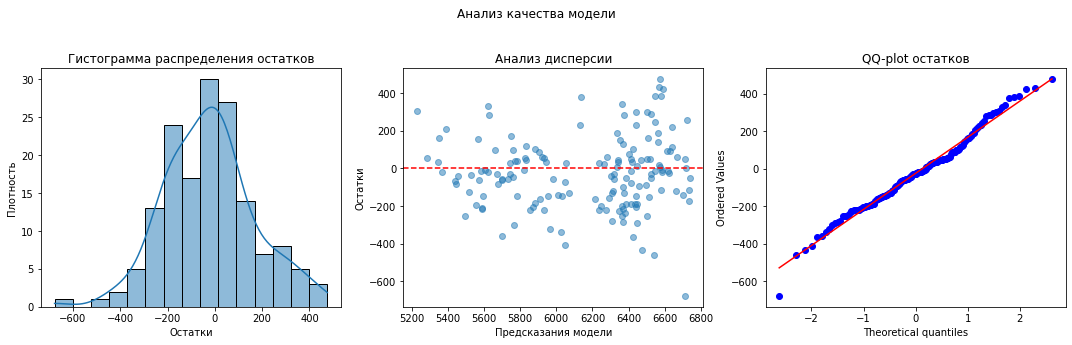

None

In [61]:
df = df_main_2
y = 'milk_yield'
cat_col_names = ['breed', 'type_pasture', 'dad_breed', 'age', 'spr']
num_col_names = ['efu_sqr', 'raw_protein']


display(f'R2: {R2(model, df, y, cat_col_names, num_col_names)}')
display(f'MSE: {MSE(model, df, y, cat_col_names, num_col_names)}')
display(f'MAE: {MAE(model, df, y, cat_col_names, num_col_names)}')
display(f'RSME: {RSME(model, df, y, cat_col_names, num_col_names)}')
display(quality_model_alternative(model, df, y, cat_col_names, num_col_names))

**Выводы:**
* По гистограмме смещение всё ещё есть, однако ситуация лучше;
* Дисперсия стала лучше, но можно ещё улучшить;
* По R2, MSE, MAE, RSME видно, что качество модели улучшилось;
* QQ-plot показывает улучшение результатов, однако есть один выброс. 

### 5.3. Обучение третьей модели

In [62]:
df_main_2 = df_main_2.merge(df_dad, on='id')

'R2: 0.8247542745210408'

'MSE: 35673.88988618191'

'MAE: 146.16302445362308'

'RSME: 188.8753289505591'

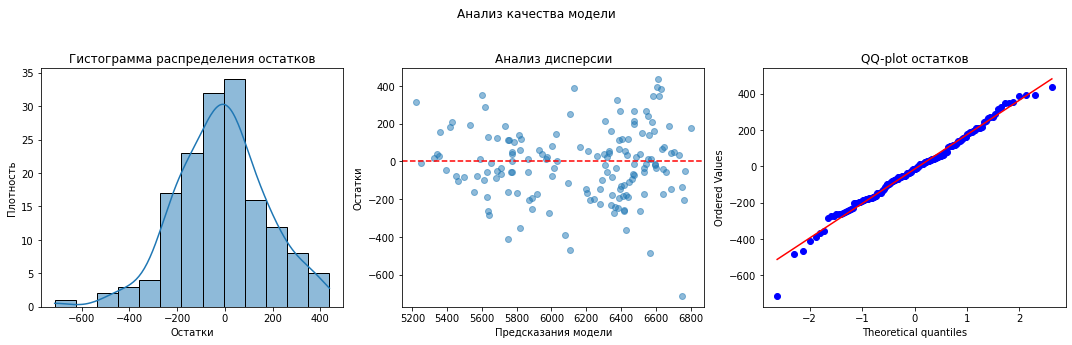

In [63]:
df = df_main_2
y = 'milk_yield'
cat_col_names = ['breed', 'type_pasture', 'dad_breed', 'age', 'spr', 'dad_name']
num_col_names = ['efu_sqr', 'raw_protein']

RANDOM_STATE = 42

X = df.drop(y, axis=1)
y = df[y]

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
random_state=RANDOM_STATE
)

encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
X_train_ohe = encoder.fit_transform(X_train[cat_col_names])
X_test_ohe = encoder.transform(X_test[cat_col_names])

encoder_col_names = encoder.get_feature_names_out(cat_col_names)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_col_names])
X_test_scaled = scaler.transform(X_test[num_col_names])

X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)

X_train = pd.concat([X_train_ohe, X_train_scaled.set_index(X_train_ohe.index)], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled.set_index(X_test_ohe.index)], axis=1)

model_lr  = LinearRegression()
model_lr.fit(X_train, y_train)

predictions = model_lr.predict(X_test)

r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mse)


display(f'R2: {r2}')
display(f'MSE: {mse}')
display(f'MAE: {mae}')
display(f'RSME: {rmse}')
 
predicted_values = predictions 
actual_values = y_test

residuals = actual_values - predicted_values

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5)) 
fig.suptitle("Анализ качества модели")

sns.histplot(residuals, ax=axes[0], kde=True)  
axes[0].set(title='Гистограмма распределения остатков', xlabel='Остатки', ylabel='Плотность')

axes[1].scatter(predicted_values, residuals, alpha=0.5) 
axes[1].set(xlabel='Предсказания модели', ylabel='Остатки', title='Анализ дисперсии')
axes[1].axhline(y=0, color='r', linestyle='--')  

st.probplot(residuals, dist="norm", plot=axes[2]) 
axes[2].set_title("QQ-plot остатков")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [64]:
confidence = 0.95
sample_mean = np.mean(predictions)

standard_error = st.sem(predictions)

degrees_of_freedom = len(predictions) - 1

interval = st.t.interval(confidence, degrees_of_freedom, loc=sample_mean, scale=standard_error)

print(f'Доверительный интервал (t-распределение): {interval[0].round(2)} - {interval[1].round(2)}')

Доверительный интервал (t-распределение): 6091.84 - 6221.88


**Выводы**
* По гистограмме смещение всё ещё есть, но ситуация улучшилась;
* Дисперсия стала более равномерной;
* QQ-plot показывает улучшение результатов, практически все точки прилипли к линии вплотную;
* По итогу обучения моделей и анализа метрик качества, самая лучшая третья.

### 5.4. Прогноз удоя у покупных коров

In [65]:
df_cow_buy['efu'] = (df_main_2['efu'].mean() * 1.05).round(2)
df_cow_buy['efu_sqr'] = (df_cow_buy['efu']**2).round(2)
df_cow_buy['raw_protein'] = (df_main_2['raw_protein'].mean() * 1.05).round(2)
df_cow_buy['spr'] = df_main['spr'].mean() * 1.05
df_cow_buy['spr'] = df_cow_buy['spr'].apply(lambda x: 'более_0.92' if x > 0.92 else 'менее_0.92')

In [66]:
df_cow_buy = df_cow_buy.reset_index(drop=True)

In [67]:
cat_col_names = ['breed', 'type_pasture', 'dad_breed', 'age', 'spr', 'dad_name']
num_col_names = ['efu_sqr', 'raw_protein']

X_cow_buy = df_cow_buy.copy()
X_cow_ohe = encoder.transform(X_cow_buy[cat_col_names])
X_cow_scaled = scaler.transform(X_cow_buy[num_col_names])
encoder_col_names = encoder.get_feature_names_out(cat_col_names)
X_cow_ohe = pd.DataFrame(X_cow_ohe, columns=encoder_col_names)
X_cow_scaled = pd.DataFrame(X_cow_scaled, columns=num_col_names)
X_cow_buy = pd.concat([X_cow_ohe, X_cow_scaled.set_index(X_cow_ohe.index)], axis=1)
predictions = model_lr.predict(X_cow_buy).round(0)

for i in range(len(df_cow_buy)):
    df_cow_buy.loc[i,'milk_yield'] = predictions[i]

df_cow_buy_2 = df_cow_buy[df_cow_buy['milk_yield'] > 6090][:]
display(df_cow_buy_2)

,breed,type_pasture,dad_breed,dad_name,fat_content,protein,age,efu,efu_sqr,raw_protein,spr,milk_yield
0,вис бик айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет,15.28,233.48,2019.95,более_0.92,6610.0
1,вис бик айдиал,равнинное,соверин,буйный,3.54,3.081,менее_2_лет,15.28,233.48,2019.95,более_0.92,6379.0
2,рефлешн соверинг,равнинное,соверин,барин,3.59,3.074,более_2_лет,15.28,233.48,2019.95,более_0.92,6285.0
3,рефлешн соверинг,холмистое,айдиал,буйный,3.40,3.061,более_2_лет,15.28,233.48,2019.95,более_0.92,6594.0
4,рефлешн соверинг,равнинное,айдиал,буйный,3.64,3.074,более_2_лет,15.28,233.48,2019.95,более_0.92,6543.0
5,рефлешн соверинг,равнинное,соверин,геркулес,3.63,3.053,менее_2_лет,15.28,233.48,2019.95,более_0.92,6426.0
6,вис бик айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет,15.28,233.48,2019.95,более_0.92,6610.0
7,вис бик айдиал,равнинное,соверин,буйный,3.57,3.079,более_2_лет,15.28,233.48,2019.95,более_0.92,6572.0
8,рефлешн соверинг,равнинное,соверин,барин,3.59,3.074,более_2_лет,15.28,233.48,2019.95,более_0.92,6285.0
9,рефлешн соверинг,холмистое,айдиал,буйный,3.40,3.079,менее_2_лет,15.28,233.48,2019.95,более_0.92,6401.0


**Выводы**
* Были построены три модели, по метрикам качества самая точная получилась третья;
* Значения метрик качества лучшей модели R2: 0.82, MSE: 35673.89, MAE: 146.16, RSME: 188.88;
* Была применена модель для прогноза удоя коров и отфильтрованы с удоем не меньше 6090 литров.

## 6. Обучение модели логистической регрессии

In [68]:
cat_col_names = ['breed', 'type_pasture', 'dad_breed', 'age']
num_col_names = ['efu', 'raw_protein', 'fat_content', 'protein', 'spr']
df_cow_buy_2['spr'] = df_main['spr'].mean() * 1.05

In [69]:
df_main['taste_milk'] = df_main['taste_milk'].apply(lambda x: 1 if x == 'вкусно' else 0)
df_cow_buy_2['taste_milk'] = 0

'Accuracy: 0.6050955414012739'

'Recall: 0.8409090909090909'

'Precision: 0.6065573770491803'

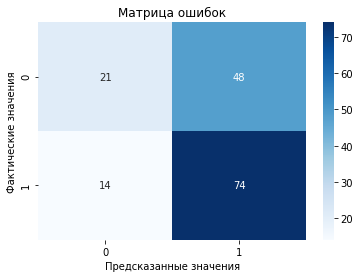

In [70]:
RANDOM_STATE = 42

X = df_main.drop('taste_milk', axis=1)
y = df_main['taste_milk']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=RANDOM_STATE)

encoder = OneHotEncoder(drop='first', sparse_output=False)
X_train_ohe = encoder.fit_transform(X_train[cat_col_names])
X_test_ohe = encoder.transform(X_test[cat_col_names])

encoder_col_names = encoder.get_feature_names_out()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_col_names])
X_test_scaled = scaler.transform(X_test[num_col_names])

X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)

X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

clf = LogisticRegression()

clf = clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)


display(f'Accuracy: {accuracy}')
display(f'Recall: {recall}')
display(f'Precision: {precision}')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказанные значения')
plt.ylabel('Фактические значения')
plt.title('Матрица ошибок')
plt.show()

**Выводы**
* Для заказчика важнее, чтобы молоко не было не вкусным. Поэтому критичнее ошибка первого рода (False Positive), когда модель предсказывает вкусное молоко, а на самом деле оно невкусное. В этом случае, покупатель потеряет выгоду.
* Следовательно, нам важнее максимизировать Precision.

In [71]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:,1]

df = pd.DataFrame(list(zip(y_test, y_proba, y_pred)), columns=['y_valid', 'y_proba', 'y_pred'])
df = df.sort_values(by='y_proba', ascending=False)

display(df.head())

,y_valid,y_proba,y_pred
33,0,0.848358,1
17,1,0.827956,1
85,1,0.819905,1
66,1,0.809939,1
95,1,0.790450,1


In [72]:
start_threshold = 0.5
stop_threshold = 1.0
num_thresholds = 1000
thresholds = [round(i, 2) for i in np.linspace(start_threshold, stop_threshold, num=num_thresholds, endpoint=False)]
columns = []

for i in thresholds:
    column_name = 'y_pred_' + str(i)
    columns.append(column_name)
    df[column_name] = df['y_proba'].apply(lambda x: 1 if x >= i else 0)

'Threshold 0.81:'

'Accuracy: 0.4585987261146497'

'Recall: 0.03409090909090909'

'Precision: 1.0'

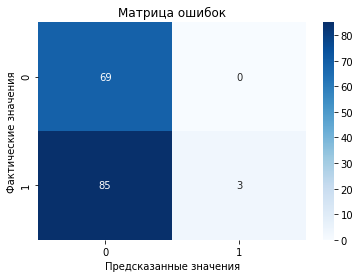

In [73]:
for i in thresholds:
    cm = confusion_matrix(y_test, df['y_pred_'+str(i)])
    if cm[0][1] == 0:
        precision = precision_score(y_test, df['y_pred_'+str(i)])
        porog = i
        break
        
accuracy = accuracy_score(y_test, df['y_pred_'+str(porog)])
precision = precision_score(y_test, df['y_pred_'+str(porog)])
recall = recall_score(y_test, df['y_pred_'+str(porog)])

display(f'Threshold {porog}:')
display(f'Accuracy: {accuracy}')
display(f'Recall: {recall}')
display(f'Precision: {precision}')

cm = confusion_matrix(y_test, df['y_pred_'+str(porog)])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказанные значения')
plt.ylabel('Фактические значения')
plt.title('Матрица ошибок')
plt.show()

**Выводы:**
* Изначально у модели был приемлемый accuracy, но precision был недостаточно высок.
* Снижение порога позволило увеличить precision, но при этом уменьшился Recall. 

In [74]:
X_cow = df_cow_buy_2

X_cow_ohe = encoder.transform(X_cow[cat_col_names])
X_cow_scaled = scaler.transform(X_cow[num_col_names])
X_cow_ohe = pd.DataFrame(X_cow_ohe, columns=encoder_col_names)
X_cow_scaled = pd.DataFrame(X_cow_scaled, columns=num_col_names)
X_cow = pd.concat([X_cow_ohe, X_cow_scaled], axis=1)

y_pred = clf.predict_proba(X_cow)[:,1]
df_cow_buy_2['y_pred'] = y_pred
df_cow_buy_2['taste_milk'] = df_cow_buy_2['y_pred'].apply(lambda x: '1' if x >= porog else '0')
df_cow_buy_2 = df_cow_buy_2.sort_values(by = ['y_pred'], ascending = False).drop(columns='y_pred')

display(df_cow_buy_2[df_cow_buy_2['taste_milk'] == '1'])

,breed,type_pasture,dad_breed,dad_name,fat_content,protein,age,efu,efu_sqr,raw_protein,spr,milk_yield,taste_milk
9,рефлешн соверинг,холмистое,айдиал,буйный,3.4,3.079,менее_2_лет,15.28,233.48,2019.95,0.958744,6401.0,1


**Выводы:**
Был получен только один удовлетворительный вариант, более 6090 литров и чтоб вкус молока был вкусным.

## Итоговые выводы

Проведенный анализ данных о надоях коров и вкусовых качествах молока позволил получить ценные инсайты и построить модель для прогнозирования удоев с акцентом на минимизацию риска получения невкусного молока. Ниже представлены основные этапы и полученные результаты:  

1. **Подготовка и очистка данных:** Обнаружены и исправлены ошибки в типах данных и названиях столбцов в исходных таблицах (df_main, df_cow_buy, df_dad). Удалены явные и неявные дубликаты, а также выбросы (например, аномально высокий удой). Данные приведены к нижнему регистру для обеспечения консистентности.

2. **Исследовательский анализ данных:** Удой распределен нормально, средний удой составляет более 6100 кг. Проанализированы распределения ЭКЕ, сырого протеина, содержания жира и белка в молоке, а также соотношения протеина к сахару. Выявлено преобладание породы вис бик айдиал, холмистого типа пастбища и вкусного молока. Большинство коров старше 2 лет. Определено распределение отцов коров (Баррин, Буйный, Соловчик, Геркулес). Проанализированы характеристики коров для покупки (содержание жира и белка в молоке, порода, тип пастбища, отец и возраст).

3. **Анализ корреляций и мультиколлинеарности:** Обнаружена сильная линейная связь между удоем молока и ЭКЕ (которую можно описать дугой) и слабая линейная связь с сырым протеином. Исключена мультиколлинеарность признаков. Выявлен признак СПО, который можно рассматривать как категориальный фактор, влияющий на удой.

4. **Построение и оценка моделей машинного обучения:** Построено и протестировано три модели для прогнозирования удоя. Внесены корректировки для улучшения этих характеристик. На основе метрик качества (R2, MSE, MAE, RMSE) выбрана лучшая модель, которая показала следующие результаты: R2: 0.82, MSE: 35673.89, MAE: 146.16, RMSE: 188.88.

6. **Оптимизация модели с учетом бизнес-требований (вкусовые качества молока):** Определено, что для заказчика наиболее критичной является ошибка первого рода (False Positive) – прогнозирование вкусного молока, когда на самом деле оно невкусное. Это связано с потенциальными убытками для покупателя. Следовательно, необходимо максимизировать Precision (точность). Проведена корректировка порога классификации для увеличения Precision, что привело к снижению Recall (полноты).

По итогу получен список коров, удовлетворяющих двум критериям: прогнозируемый удой не менее 6090 литров и "вкусное" молоко (с учетом оптимизированного порога для максимизации Precision).

**Рекомендации:**

* Для дальнейшего улучшения модели рекомендуется сбор и анализ большего объема данных.
* Можно рассмотреть добавление новых признаков, которые могут влиять на удой и вкус молока (например, генетические факторы, подробные данные о рационе питания).
* Необходимо регулярно пересматривать порог классификации, учитывая изменяющиеся бизнес-требования и данные.
* Следует продолжить мониторинг остатков модели, чтобы убедиться в их нормальном распределении и гомоскедастичности.
* При принятии окончательного решения о покупке коров учитывайте не только прогнозируемый удой и вкус молока, но и стоимость коров, затраты на их содержание и другие экономические факторы.

Выполнил Лосевский Дмитрий